# LSTM Train Model

## Base Initialization

### Global Parameters

In [1]:
stock_code = "GAS"
output_range = (0, 200)

In [2]:
output_column = "close"

In [3]:
stock_code = str.lower(stock_code)

### Install libraries

In [4]:
# !pip install -r requirements.txt

### Import libraries

In [5]:
import os
import sys
import random
import numpy as np
import torch

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from data_preprocessor.data_preprocessor import DataPreprocessor
from dtos.model_dtos.model_config_dto import ModelConfigDto
from logger.logger import Logger, LogType
from model.lstm_model import LSTM_Model
from train_test_creator.train_test_creator import TrainTestCreator
from web_scraper.web_scraper import WebScraper
from utils.constants import *
from utils.enums import *
from utils.utils import plot_model_result

In [6]:
SEED = RANDOM_SEED

# Apply globally
random.seed(SEED)
np.random.seed(SEED)

In [7]:
# train_window_size = DEFAULT_TRAIN_WINDOW_SIZE
# validation_window_size = DEFAULT_VALIDATION_WINDOW_SIZE
# test_window_size = DEFAULT_TEST_WINDOW_SIZE

train_window_size = 450
validation_window_size = 30
test_window_size = 30

print(f"Train window size: {train_window_size}")
print(f"Validation window size: {validation_window_size}")
print(f"Test window size: {test_window_size}")

Train window size: 450
Validation window size: 30
Test window size: 30


### Log Metadata

In [8]:
my_logger = Logger(
    file_name=f"{TRAINED_MODELS_LOG_FILE_BASE}/{stock_code}_lstm_train_log"
)

In [9]:
my_logger.log_info(
    f"\nTRAIN MODEL FOR STOCK: '{stock_code}' - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"
)

### Load Dataframe

In [10]:
my_train_test_creator = TrainTestCreator(logger=my_logger)

In [11]:
dataframe = my_train_test_creator.load_dataframe(
    stock_code=stock_code, file_path=f"../../unified_dataframe/unified_{stock_code}.csv"
)
dataframe

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,is_quarter_end,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos
0,2012-05-21,4.106192,38.969542,535.227419,252.423263,20.790000,541.473871,56.880000,40.650000,1302.951968,...,0,3,1,2,5.000000e-01,-0.866025,0.000000,1.000000,0.642055,-0.766659
1,2012-05-22,4.108274,38.982012,536.679677,252.504039,20.930000,538.755484,56.930000,40.700000,1303.368913,...,0,4,1,2,5.000000e-01,-0.866025,0.781831,0.623490,0.628763,-0.777597
2,2012-05-23,4.110356,38.994483,538.131935,252.584814,21.070000,536.037097,56.980000,40.750000,1303.785857,...,0,4,1,2,5.000000e-01,-0.866025,0.974928,-0.222521,0.615285,-0.788305
3,2012-05-24,4.112438,39.006953,539.584194,252.665590,21.210000,533.318710,57.030000,40.800000,1304.202802,...,0,4,1,2,5.000000e-01,-0.866025,0.433884,-0.900969,0.601624,-0.798779
4,2012-05-25,4.114521,39.019423,541.036452,252.746365,21.350000,530.600323,57.080000,40.850000,1304.619746,...,0,4,1,2,5.000000e-01,-0.866025,-0.433884,-0.900969,0.587785,-0.809017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3264,2025-06-20,7.846813,106.966667,936.533333,579.360000,72.863333,315.580000,222.863333,224.926667,2770.786667,...,0,3,1,3,1.224647e-16,-1.000000,-0.433884,-0.900969,0.196673,-0.980469
3265,2025-06-23,7.880769,106.676667,927.445333,586.434000,71.482333,302.707000,222.304333,227.240667,2738.915667,...,0,4,1,3,1.224647e-16,-1.000000,0.000000,1.000000,0.145799,-0.989314
3266,2025-06-25,7.903407,106.483333,921.386667,591.150000,70.561667,294.125000,221.931667,228.783333,2717.668333,...,0,4,1,3,1.224647e-16,-1.000000,0.974928,-0.222521,0.111659,-0.993747
3267,2025-06-26,7.914725,106.386667,918.357333,593.508000,70.101333,289.834000,221.745333,229.554667,2707.044667,...,0,4,1,3,1.224647e-16,-1.000000,0.433884,-0.900969,0.094537,-0.995521


In [12]:
dataframe.shape

(3269, 223)

## Create train test set

In [13]:
train_test_set = my_train_test_creator.create_train_test_set(
    dataframe=dataframe,
    output_column=output_column,
    output_range=output_range,
    stock_code=stock_code,
    train_window_size=train_window_size,
    validation_window_size=validation_window_size,
    test_window_size=test_window_size,
)

Feature Selector Types:
['XGB_REGRESSOR', 'LASSO', 'ELASTIC_NET', 'XGB_SHAP']

Fitting feature selectors...

Fitting XGB feature selector...
Done fitting XGB feature selector...
Fitting LASSO feature selector...


d:\GIT\master-thesis\mt_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.440e+02, tolerance: 1.190e+02
  model = cd_fast.enet_coordinate_descent(


Done fitting LASSO feature selector...
Fitting ELASTC NET feature selector...
Done fitting ELASTC NET feature selector...
Fitting XGB SHAP feature selector...
Done fitting XGB SHAP feature selector...

Done fitting feature selectors...
🔍 Dropped 14 highly correlated features (|r| >= 0.85):
['dow_jones_close', 'labor_female', 'low', 'oil_price_close', 'oil_price_high', 'oil_price_open', 'open', 'rrrr_refinancing_rate', 'vn_30_index_change_percentage', 'vn_30_index_close', 'vn_index_close', 'vn_index_high', 'vn_index_low', 'vn_index_open']
✅ Kept 26 features after pruning correlation redundancy.


In [14]:
print(f"Number of training samples: {train_test_set.get_number_of_train_windows()}")

Number of training samples: 82


In [15]:
train_test_set.get_train_window(0)

,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,xpi_coffee,...,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos,close
0,0.517953,0.000000,0.312368,0.113804,0.176953,0.728733,0.051864,0.035475,0.000000,0.410965,...,0.50,0.0,0.333333,0.75,0.066987,0.307979,1.000000e+00,0.821030,0.116654,0.088468
1,0.518058,0.000175,0.314136,0.113893,0.178899,0.724246,0.051997,0.035636,0.000099,0.414315,...,0.75,0.0,0.333333,0.75,0.066987,0.862937,8.019377e-01,0.814384,0.111185,0.092783
2,0.518163,0.000349,0.315905,0.113983,0.180845,0.719759,0.052130,0.035797,0.000197,0.417664,...,0.75,0.0,0.333333,0.75,0.066987,1.000000,3.568959e-01,0.807645,0.105831,0.088252
3,0.518268,0.000524,0.317673,0.114073,0.182791,0.715272,0.052263,0.035958,0.000296,0.421014,...,0.75,0.0,0.333333,0.75,0.066987,0.615957,5.840301e-17,0.800815,0.100594,0.083936
4,0.518373,0.000698,0.319441,0.114163,0.184737,0.710784,0.052396,0.036119,0.000395,0.424363,...,0.75,0.0,0.333333,0.75,0.066987,0.000000,0.000000e+00,0.793895,0.095475,0.084152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
505,0.574467,0.129504,0.468586,0.180398,0.279242,0.170043,0.079996,0.130947,0.073189,0.244175,...,0.00,0.0,0.666667,0.50,0.000000,0.307979,1.000000e+00,0.743139,0.063079,0.235262
506,0.574601,0.129679,0.467583,0.180488,0.280206,0.171821,0.079886,0.132527,0.073288,0.241305,...,0.00,0.0,0.666667,0.50,0.000000,0.862937,8.019377e-01,0.735582,0.058959,0.238918
507,0.574735,0.129853,0.466581,0.180578,0.281169,0.173599,0.079775,0.134107,0.073386,0.238434,...,0.00,0.0,0.666667,0.50,0.000000,1.000000,3.568959e-01,0.727955,0.054969,0.240137
508,0.574869,0.130028,0.465578,0.180668,0.282133,0.175377,0.079664,0.135687,0.073485,0.235563,...,0.00,0.0,0.666667,0.50,0.000000,0.615957,5.840301e-17,0.720261,0.051111,0.237700


In [16]:
train_test_set.get_train_window().shape

(510, 207)

In [17]:
train_test_set.get_test_set()

,date,gdp_gdp_growth,xpi_animal_feed_and_raw_materials,xpi_aquatic_products,xpi_cameras_camcorders_and_components,xpi_cashew_nuts,xpi_cassava_and_cassava_products,xpi_chemical_products,xpi_chemicals,xpi_clinker_and_cement,...,week_of_month,half_of_year,season,month_sin,month_cos,day_of_week_sin,day_of_week_cos,day_of_year_sin,day_of_year_cos,close
0,2024-02-15,6.184176,92.429519,636.896552,744.827586,54.482759,393.103448,228.965517,219.310345,2379.310345,...,3,1,1,8.660254e-01,5.000000e-01,0.433884,-0.900969,0.711657,0.702527,68.887
1,2024-02-16,6.172527,92.441989,630.689655,734.482759,53.448276,379.310345,226.896552,217.931034,2337.931034,...,3,1,1,8.660254e-01,5.000000e-01,-0.433884,-0.900969,0.723644,0.690173,69.706
2,2024-04-19,5.925165,93.227615,701.946333,720.000000,61.333333,286.666667,287.000000,250.000000,2795.000000,...,3,1,2,8.660254e-01,-5.000000e-01,-0.433884,-0.900969,0.948362,-0.317191,68.250
3,2024-02-19,6.137582,92.479400,612.068966,703.448276,50.344828,337.931034,220.689655,213.793103,2213.793103,...,3,1,1,8.660254e-01,5.000000e-01,0.000000,1.000000,0.758306,0.651899,72.163
4,2024-02-20,6.125934,92.491870,605.862069,693.103448,49.310345,324.137931,218.620690,212.413793,2172.413793,...,3,1,1,8.660254e-01,5.000000e-01,0.781831,0.623490,0.769415,0.638749,71.526
5,2024-02-21,6.114286,92.504340,599.655172,682.758621,48.275862,310.344828,216.551724,211.034483,2131.034483,...,3,1,1,8.660254e-01,5.000000e-01,0.974928,-0.222521,0.780296,0.625411,70.707
6,2024-04-25,6.008901,93.302437,717.248333,720.000000,63.333333,266.666667,245.000000,250.000000,2825.000000,...,4,1,2,8.660254e-01,-5.000000e-01,0.433884,-0.900969,0.910605,-0.413279,67.340
7,2024-02-22,6.102637,92.516811,593.448276,672.413793,47.241379,296.551724,214.482759,209.655172,2089.655172,...,4,1,1,8.660254e-01,5.000000e-01,0.433884,-0.900969,0.790946,0.611886,70.889
8,2024-02-23,6.090989,92.529281,587.241379,662.068966,46.206897,282.758621,212.413793,208.275862,2048.275862,...,4,1,1,8.660254e-01,5.000000e-01,-0.433884,-0.900969,0.801361,0.598181,69.524
9,2024-02-26,6.056044,92.566692,568.620690,631.034483,43.103448,241.379310,206.206897,204.137931,1924.137931,...,4,1,1,8.660254e-01,5.000000e-01,0.000000,1.000000,0.831171,0.556017,69.342


In [18]:
train_test_set.get_test_set().shape

(30, 223)

## Setup model

In [19]:
lstm_model_config = ModelConfigDto(
    # Metadata
    entity=WANDB_ENTITY_NAME,
    project=WANDB_PROJECT_NAME,
    architecture=AchitectureType.LSTM,
    stock_code=stock_code,
    # Windowing
    window_type=WindowType.SLIDING,
    train_window_size=train_window_size,
    validation_window_size=validation_window_size,
    test_window_size=test_window_size,
    # Training
    epochs=400,
    learning_rate=0.001,
    batch_size=64,
    optimizer=OptimizerType.ADAM,
    loss_fn=LossFunctionType.MSE,
    # Data & metrics
    scaler_type=ScalerType.MINMAX,
    metric=MetricType.MAPE,
    # Reproducibility & runtime
    seed=RANDOM_SEED,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
)
lstm_model_config.format_config()

{
    "entity": "trung-lyduc18",
    "project": "master_thesis",
    "architecture": "lstm",
    "stock_code": "gas",
    "window_type": "sliding",
    "train_window_size": 450,
    "validation_window_size": 30,
    "test_window_size": 30,
    "epochs": 400,
    "learning_rate": 0.001,
    "batch_size": 64,
    "optimizer": "adam",
    "loss_fn": "mse",
    "scaler_type": "minmax",
    "metric": "mape",
    "device": "cuda",
    "seed": 42
}


In [20]:
my_lstm_model = LSTM_Model(
    logger=my_logger, train_test_set=train_test_set, model_config=lstm_model_config
)

PyTorch version: 2.5.1+cu121


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\ADMIN\_netrc
wandb: Currently logged in as: trung-lyduc18 (retsam-deep-learning) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Start training the model

In [21]:
model_output_dto = my_lstm_model.train()

Training on cuda for 400 epochs...



Epoch 1:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [1/400] - Train: 0.10781167 | Val: 0.10009652


Epoch 2:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [2/400] - Train: 0.09537702 | Val: 0.08500071


...

Epoch 96:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch [96/400] - Train: 0.00056716 | Val: 0.00037651


Epoch 97:   0%|          | 0/2 [00:00<?, ?it/s]

Early stopping at epoch 97 (best val loss: 0.000369)
Training completed in 10.37s | Test MAPE: 2.61%


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█
train_loss,█▇▅▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,96
train_loss,0.00057
val_loss,0.00038


In [22]:
model_output_dto.y_pred_denorm

array([71.54387 , 70.46826 , 72.6053  , 70.67511 , 71.23478 , 71.41985 ,
       70.77581 , 70.7616  , 72.23744 , 70.22356 , 70.48998 , 71.2664  ,
       71.06262 , 69.233826, 71.60241 , 69.90883 , 69.882355, 71.40981 ,
       71.03295 , 72.668045, 70.229324, 71.53242 , 69.44953 , 69.908104,
       71.67393 , 70.523125, 69.643616, 70.783676, 70.81565 , 69.97244 ],
      dtype=float32)

In [23]:
model_output_dto.y_true

array([68.887, 69.706, 68.25 , 72.163, 71.526, 70.707, 67.34 , 70.889,
       69.524, 69.342, 70.616, 70.98 , 70.434, 70.616, 70.798, 71.89 ,
       72.982, 73.164, 72.345, 70.798, 70.889, 71.89 , 73.71 , 74.893,
       70.889, 72.982, 72.527, 73.71 , 73.71 , 73.255], dtype=float32)

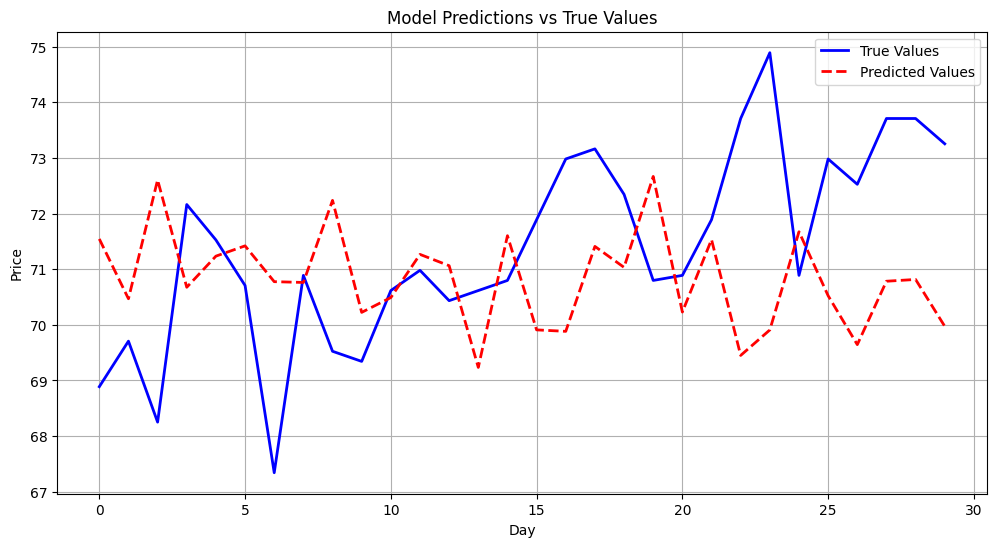

In [24]:
plot_model_result(model_output_dto=model_output_dto)